In [2]:
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder

import cv2
from PIL import Image

from sklearn.model_selection import train_test_split

In [3]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from collections import Counter
import random
import pandas as pd
from IPython.display import display

In [4]:
DATA_PATH = "./Dataset"

In [5]:
class BrainData(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform

        self.dataset = ImageFolder(root=root_dir)
        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img_path, label = self.dataset.samples[idx]

        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "label": label,
            "class_name": self.idx_to_class[label],
            "path": img_path
        }

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [7]:
brain_data = BrainData(root_dir=DATA_PATH, transform=transform)

print(brain_data.classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


Samples per class:
glioma: 5625
meningioma: 3978
notumor: 3847
pituitary: 4363

Total samples: 17813


,class_name,count,percentage
0,glioma,5625,31.58%
1,meningioma,3978,22.33%
2,notumor,3847,21.60%
3,pituitary,4363,24.49%


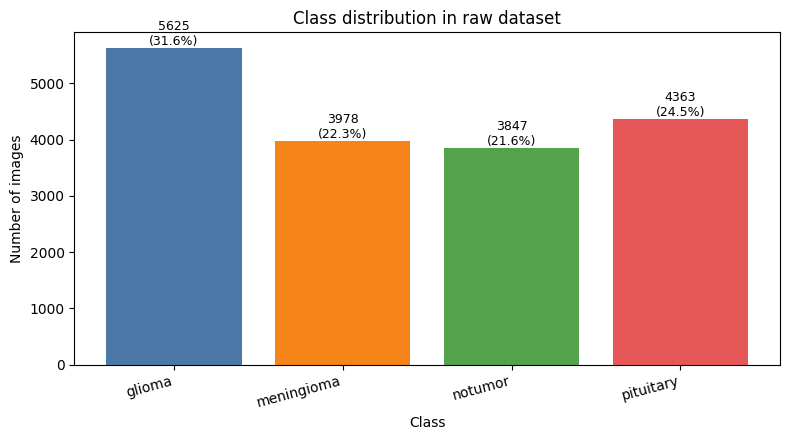

Class imbalance ratio (max/min): 1.46x

File extension distribution: {'.jpg': 17813}


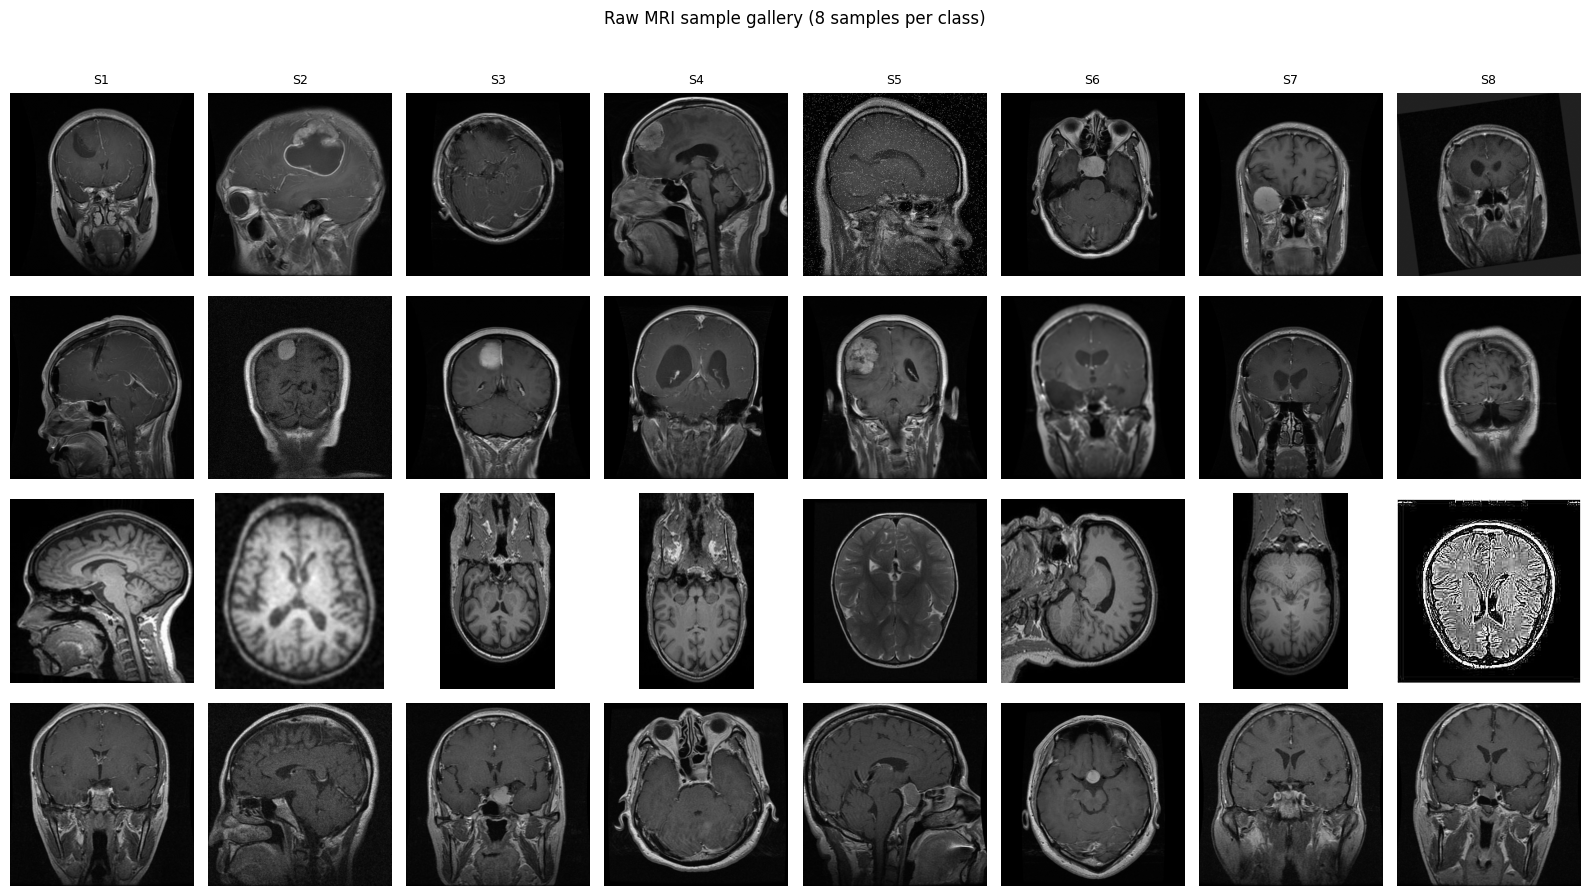

Corruption check: no unreadable images found.
Intensity stats computed from up to 200 images per class.


,class_name,sampled_images,pixel_count,min,max,mean,std,p5,p50,p95
0,glioma,200,52428800,0.000000,255.000000,36.57,41.60,0.00,15.00,114.00
1,meningioma,200,50400362,0.000000,255.000000,40.44,46.29,0.00,21.00,128.00
2,notumor,200,25522954,0.000000,255.000000,57.12,60.99,0.00,36.00,176.00
3,pituitary,200,51211684,0.000000,255.000000,47.20,42.16,0.00,47.00,122.00


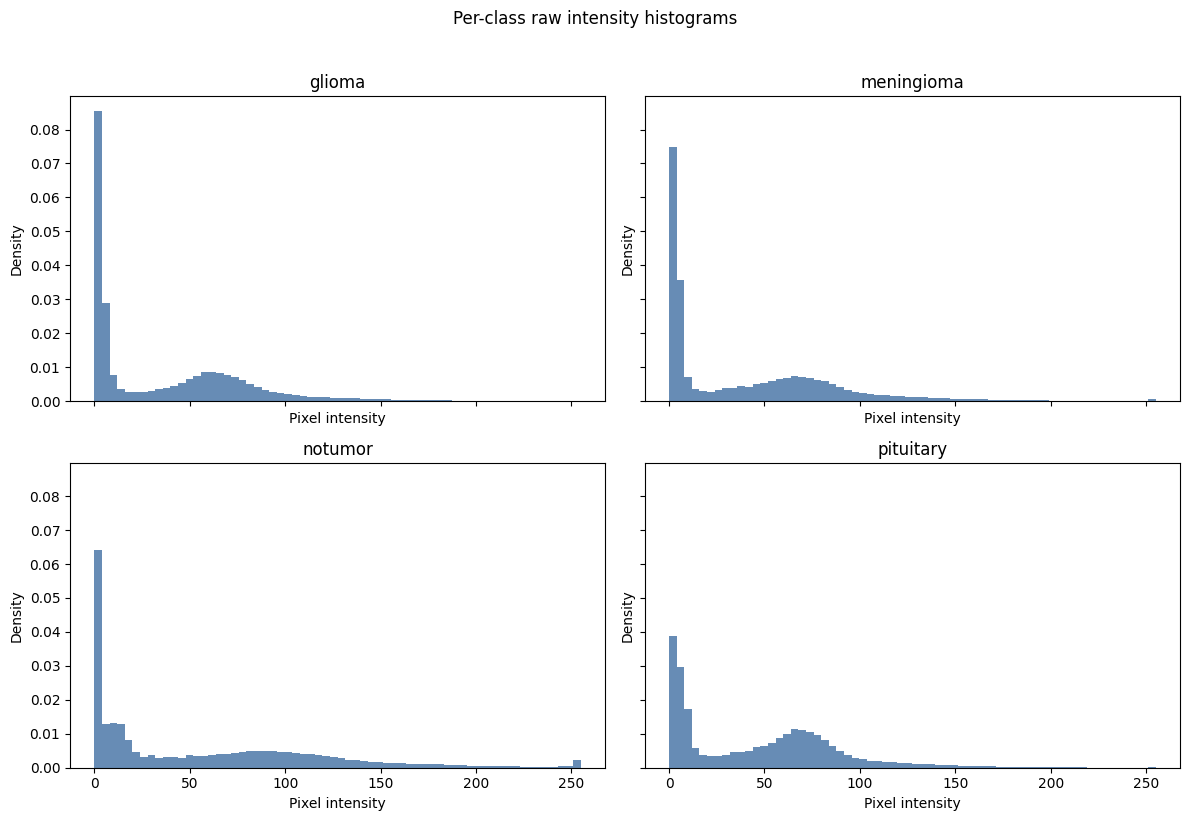

In [ ]:
RANDOM_SEED = 7
SAMPLES_PER_CLASS = 8
HIST_BINS = 64
MAX_HIST_SAMPLES_PER_CLASS = 200

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def collect_class_image_paths(root_dir):
    root = Path(root_dir)
    paths_by_class = {}
    for class_name in sorted([d.name for d in root.iterdir() if d.is_dir()]):
        class_dir = root / class_name
        image_paths = sorted([p for p in class_dir.iterdir() if p.is_file()])
        paths_by_class[class_name] = image_paths
    return paths_by_class

def safe_read_gray(img_path):
    return cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

def sample_paths(paths, n_samples, seed=42):
    if len(paths) <= n_samples:
        return paths
    rng = random.Random(seed)
    return rng.sample(paths, n_samples)

def sample_paths_by_class(paths_by_class, n_per_class=8, seed=42):
    sampled = {}
    for i, (class_name, paths) in enumerate(paths_by_class.items()):
        sampled[class_name] = sample_paths(paths, n_per_class, seed + i)
    return sampled

# def summarize_file_sizes(paths_by_class):
#     rows = []
#     for class_name, paths in paths_by_class.items():
#         if not paths:
#             continue
#         sizes_kb = np.array([p.stat().st_size / 1024.0 for p in paths], dtype=np.float32)
#         rows.append({
#             "class_name": class_name,
#             "count": int(len(sizes_kb)),
#             "min_kb": float(np.min(sizes_kb)),
#             "q1_kb": float(np.percentile(sizes_kb, 25)),
#             "median_kb": float(np.median(sizes_kb)),
#             "q3_kb": float(np.percentile(sizes_kb, 75)),
#             "max_kb": float(np.max(sizes_kb)),
#             "mean_kb": float(np.mean(sizes_kb)),
#             "std_kb": float(np.std(sizes_kb)),
#         })
#     if not rows:
#         return pd.DataFrame()
#     return pd.DataFrame(rows).sort_values("class_name").reset_index(drop=True)

def compute_intensity_stats(paths_by_class, max_samples_per_class=200, seed=42):
    rows = []
    per_class_pixels = {}

    for i, (class_name, paths) in enumerate(paths_by_class.items()):
        sampled_paths = sample_paths(paths, max_samples_per_class, seed + i)
        pixels = []
        for img_path in sampled_paths:
            img = safe_read_gray(img_path)
            if img is None:
                continue
            pixels.append(img.reshape(-1))

        if not pixels:
            continue

        all_pixels = np.concatenate(pixels).astype(np.float32)
        p5, p50, p95 = np.percentile(all_pixels, [5, 50, 95])
        rows.append({
            "class_name": class_name,
            "sampled_images": int(len(sampled_paths)),
            "pixel_count": int(len(all_pixels)),
            "min": float(np.min(all_pixels)),
            "max": float(np.max(all_pixels)),
            "mean": float(np.mean(all_pixels)),
            "std": float(np.std(all_pixels)),
            "p5": float(p5),
            "p50": float(p50),
            "p95": float(p95),
        })
        per_class_pixels[class_name] = all_pixels

    stats_df = pd.DataFrame(rows)
    if not stats_df.empty:
        stats_df = stats_df.sort_values("class_name").reset_index(drop=True)
    return stats_df, per_class_pixels

paths_by_class = collect_class_image_paths(DATA_PATH)

class_counts = Counter(brain_data.dataset.targets)
class_count_map = {brain_data.idx_to_class[idx]: class_counts[idx] for idx in sorted(brain_data.idx_to_class.keys())}
class_dist_df = pd.DataFrame({
    "class_name": list(class_count_map.keys()),
    "count": list(class_count_map.values()),
})
class_dist_df["percentage"] = (class_dist_df["count"] / class_dist_df["count"].sum()) * 100

print("Samples per class:")
for row in class_dist_df.itertuples(index=False):
    print(f"{row.class_name}: {row.count}")
print(f"\nTotal samples: {int(class_dist_df['count'].sum())}")

display(class_dist_df.style.format({"percentage": "{:.2f}%"}))

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(class_dist_df["class_name"], class_dist_df["count"], color=["#4c78a8", "#f58518", "#54a24b", "#e45756"])
for bar, pct in zip(bars, class_dist_df["percentage"]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 5, f"{int(height)}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title("Class distribution in raw dataset")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

imbalance_ratio = class_dist_df["count"].max() / class_dist_df["count"].min()
print(f"Class imbalance ratio (max/min): {imbalance_ratio:.2f}x")

extension_counts = Counter(
    p.suffix.lower()
    for class_paths in paths_by_class.values()
    for p in class_paths
    if p.suffix
  )
print("\nFile extension distribution:", dict(extension_counts))

sampled_paths_by_class = sample_paths_by_class(paths_by_class, n_per_class=SAMPLES_PER_CLASS, seed=RANDOM_SEED)
class_order = class_dist_df["class_name"].tolist()

fig, axes = plt.subplots(
    len(class_order),
    SAMPLES_PER_CLASS,
    figsize=(2.0 * SAMPLES_PER_CLASS, 2.2 * len(class_order))
  )
axes = np.array(axes)
if axes.ndim == 1:
    axes = axes[np.newaxis, :]

for row_idx, class_name in enumerate(class_order):
    class_samples = sampled_paths_by_class.get(class_name, [])
    for col_idx in range(SAMPLES_PER_CLASS):
        ax = axes[row_idx, col_idx]
        ax.axis("off")
        if col_idx < len(class_samples):
            img = safe_read_gray(class_samples[col_idx])
            if img is not None:
                ax.imshow(img, cmap="gray")
        if row_idx == 0:
            ax.set_title(f"S{col_idx + 1}", fontsize=9)
    axes[row_idx, 0].set_ylabel(class_name, rotation=0, labelpad=35, va="center")

fig.suptitle("Raw MRI sample gallery (8 samples per class)", y=1.02)
plt.tight_layout()
plt.show()

corrupt_records = []
dimension_counter = Counter()
for class_name, class_paths in paths_by_class.items():
    for img_path in class_paths:
        img = safe_read_gray(img_path)
        if img is None:
            corrupt_records.append({"class_name": class_name, "path": str(img_path)})
            continue
        h, w = img.shape
        dimension_counter[(h, w)] += 1

if not corrupt_records:
    print("Corruption check: no unreadable images found.")
else:
    corrupt_df = pd.DataFrame(corrupt_records)
    print(f"Corruption check: {len(corrupt_df)} unreadable images found.")
    display(corrupt_df.head(10))

# dim_rows = [
#     {"height": h, "width": w, "count": cnt}
#     for (h, w), cnt in dimension_counter.items()
#   ]
# dim_df = pd.DataFrame(dim_rows).sort_values("count", ascending=False).reset_index(drop=True)
# print("\nMost common raw image dimensions:")
# display(dim_df.head(10))

# size_df = summarize_file_sizes(paths_by_class)
# print("File size summary by class (KB):")
# display(size_df.style.format({
#     "min_kb": "{:.2f}",
#     "q1_kb": "{:.2f}",
#     "median_kb": "{:.2f}",
#     "q3_kb": "{:.2f}",
#     "max_kb": "{:.2f}",
#     "mean_kb": "{:.2f}",
#     "std_kb": "{:.2f}",
# }))

# size_data = [
#     np.array([p.stat().st_size / 1024.0 for p in paths_by_class[class_name]], dtype=np.float32)
#     for class_name in class_order
#   ]
# fig, ax = plt.subplots(figsize=(8, 4.5))
# ax.boxplot(size_data, labels=class_order, showfliers=False)
# ax.set_title("File size distribution by class")
# ax.set_xlabel("Class")
# ax.set_ylabel("File size (KB)")
# plt.xticks(rotation=15, ha="right")
# plt.tight_layout()
# plt.show()

intensity_stats_df, per_class_pixels = compute_intensity_stats(
    paths_by_class,
    max_samples_per_class=MAX_HIST_SAMPLES_PER_CLASS,
    seed=RANDOM_SEED
  )
print(f"Intensity stats computed from up to {MAX_HIST_SAMPLES_PER_CLASS} images per class.")
display(intensity_stats_df.style.format({
    "mean": "{:.2f}",
    "std": "{:.2f}",
    "p5": "{:.2f}",
    "p50": "{:.2f}",
    "p95": "{:.2f}",
}))

n_classes = len(class_order)
n_cols = 2
n_rows = int(np.ceil(n_classes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, class_name in enumerate(class_order):
    ax = axes[i]
    pixels = per_class_pixels.get(class_name)
    if pixels is None or len(pixels) == 0:
        ax.set_visible(False)
        continue
    ax.hist(pixels, bins=HIST_BINS, range=(0, 255), density=True, alpha=0.85, color="#4c78a8")
    ax.set_title(f"{class_name}")
    ax.set_xlabel("Pixel intensity")
    ax.set_ylabel("Density")

for i in range(n_classes, len(axes)):
    axes[i].set_visible(False)

fig.suptitle("Per-class raw intensity histograms", y=1.02)
plt.tight_layout()
plt.show()

Train distribution: Counter({0: 4500, 3: 3490, 1: 3182, 2: 3078})
Val distribution : Counter({0: 1125, 3: 873, 1: 796, 2: 769})

Train/Val split summary by class:


,class_name,train_count,val_count,train_pct,val_pct,total
0,glioma,4500,1125,80.00%,20.00%,5625
1,meningioma,3182,796,79.99%,20.01%,3978
2,notumor,3078,769,80.01%,19.99%,3847
3,pituitary,3490,873,79.99%,20.01%,4363


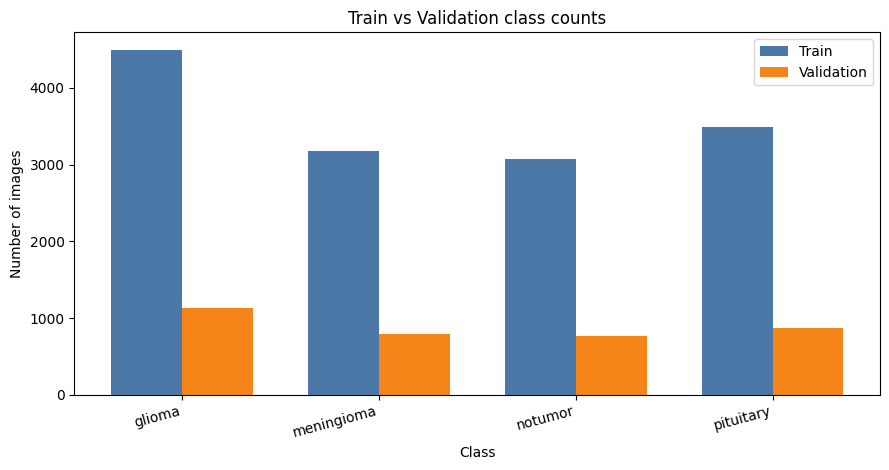

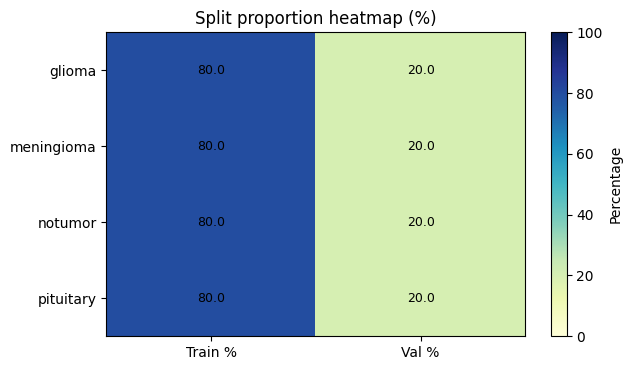

In [10]:
labels_all = np.array(brain_data.dataset.targets)
indices = np.arange(len(brain_data))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=labels_all,
)

train_targets = labels_all[train_idx]
val_targets = labels_all[val_idx]

print("Train distribution:", Counter(train_targets.tolist()))
print("Val distribution :", Counter(val_targets.tolist()))

train_counts = Counter(train_targets.tolist())
val_counts = Counter(val_targets.tolist())

split_rows = []
for idx in sorted(brain_data.idx_to_class.keys()):
    class_name = brain_data.idx_to_class[idx]
    train_count = train_counts[idx]
    val_count = val_counts[idx]
    total_count = train_count + val_count
    split_rows.append({
        "class_name": class_name,
        "train_count": train_count,
        "val_count": val_count,
        "train_pct": (train_count / total_count) * 100 if total_count else 0.0,
        "val_pct": (val_count / total_count) * 100 if total_count else 0.0,
        "total": total_count,
    })

split_df = pd.DataFrame(split_rows)
print("\nTrain/Val split summary by class:")
display(split_df.style.format({"train_pct": "{:.2f}%", "val_pct": "{:.2f}%"}))

x = np.arange(len(split_df))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(x - width / 2, split_df["train_count"], width=width, label="Train", color="#4c78a8")
ax.bar(x + width / 2, split_df["val_count"], width=width, label="Validation", color="#f58518")

ax.set_title("Train vs Validation class counts")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.set_xticks(x)
ax.set_xticklabels(split_df["class_name"], rotation=15, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

heat_data = split_df[["train_pct", "val_pct"]].to_numpy()
fig, ax = plt.subplots(figsize=(6.5, 3.8))
im = ax.imshow(heat_data, cmap="YlGnBu", aspect="auto", vmin=0, vmax=100)

ax.set_title("Split proportion heatmap (%)")
ax.set_yticks(np.arange(len(split_df)))
ax.set_yticklabels(split_df["class_name"])
ax.set_xticks([0, 1])
ax.set_xticklabels(["Train %", "Val %"])

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        ax.text(j, i, f"{heat_data[i, j]:.1f}", ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im, ax=ax, label="Percentage")
plt.tight_layout()
plt.show()

In [ ]:
def apply_clahe(image):
    image_uint8 = np.clip(image * 255.0, 0, 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(image_uint8)
    return enhanced.astype(np.float32) / 255.0


def mask_roi(image):
    _, binary = cv2.threshold((image * 255).astype(np.uint8), 25, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return image

    mask = np.zeros_like(binary, dtype=np.uint8)
    largest = max(contours, key=cv2.contourArea)
    cv2.drawContours(mask, [largest], -1, 255, -1)

    return image * (mask.astype(np.float32) / 255.0)

def image_pyramid(image, scales=(224, 112, 56)):
    pil = Image.fromarray(np.clip(image * 255.0, 0, 255).astype(np.uint8), mode="L")
    out = {}
    for s in scales:
        out[s] = np.array(pil.resize((s, s), Image.LANCZOS), dtype=np.uint8)
    return out


def denoise(img):

    u8 = np.clip(img * 255.0, 0, 255).astype(np.uint8)

    kernel = np.ones((1, 1), np.uint8)
    u8 = cv2.dilate(u8, kernel, iterations=1)
    u8 = cv2.erode(u8, kernel, iterations=3)
    u8 = cv2.morphologyEx(u8, cv2.MORPH_CLOSE, kernel)
    u8 = cv2.medianBlur(u8, 3)

    return u8.astype(np.float32) / 255.0

def preprocess_one_image(img_path, scales=(224, 112, 56)):
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        return None

    x = gray.astype(np.float32) / 255.0
    x = apply_clahe(x)
    x = mask_roi(x)
    x = denoise(x)
    pyramids = image_pyramid(x, scales=scales)
    return pyramids

def preprocess_dataset(input_root, output_root, scales=(224, 112, 56)):
    input_root = Path(input_root)
    output_root = Path(output_root)

    class_dirs = [d for d in input_root.iterdir() if d.is_dir()]

    total = 0
    processed = 0

    for class_dir in class_dirs:
        img_files = [p for p in class_dir.iterdir()]
        total += len(img_files)

        for img_path in img_files:
            pyramids = preprocess_one_image(img_path, scales=scales)
            if pyramids is None:
                continue

            for s, img_u8 in pyramids.items():
                out_dir = output_root / f"scale_{s}" / class_dir.name
                out_dir.mkdir(parents=True, exist_ok=True)
                out_path = out_dir / f"{img_path.stem}.png"
                cv2.imwrite(str(out_path), img_u8)

            processed += 1

        print(f"{class_dir.name}: {len(img_files)} files done")

    print(f"\nProcessed {processed}/{total} images")
    print(f"Saved preprocessed dataset to: {output_root.resolve()}")

preprocess_dataset(DATA_PATH, "./Dataset_preprocessed", scales=(224, 112, 56))

glioma: 5625 files done
meningioma: 3978 files done
notumor: 3847 files done
pituitary: 4363 files done

Processed 17813/17813 images
Saved preprocessed dataset to: C:\Users\aman\Desktop\code-vault\gf_clone\Dataset_preprocessed
